In Mendones v. Cushman, the plaintiffs submitted 9 deepfake videos and AI-altered images as evidence in a civil case. The judge discovered the evidence was fabricated and dismissed the entire case. This case highlights a growing threat to the justice system — AI-generated content is now realistic enough to be submitted in court as real evidence. It raises serious questions about how courts should verify the authenticity of digital evidence. Detection tools that can reliably identify AI-generated images are becoming increasingly necessary for law enforcement and the legal system. 

Wang et al. (2020) investigated whether AI-generated images produced by CNNs (a type of neural network) could be reliably detected. They found that a classifier trained on images from just one type of generator could generalize and detect images from other generators it had never seen before. However, the study also warned that as generation technology improves, detection will become harder — hence the title "surprisingly easy to spot...for now." This is directly relevant to our project because the detection tools we are evaluating were likely trained on this kind of content, not on law enforcement imagery. The question is whether those same tools still work on grainy, compressed bodycam and surveillance footage.

Search terms that worked: Person, Human body, Crowd, Pedestrian, Human face

Search terms that didn't work: Asian student, Black student, White student

Part 3: My Prompts - Surveillance/Security Category

Parking & Garage (10)
1. grainy security camera footage of person walking through parking garage
2. low quality CCTV screenshot of car entering parking garage at night
3. overhead security camera view of empty parking lot at dusk
4. blurry surveillance image of two people near vehicles in parking lot
5. night vision security camera footage of parking garage entrance
6. low resolution CCTV image of person running through parking lot
7. grainy overhead shot of cars parked in outdoor lot, security camera
8. surveillance footage of person standing next to car in parking garage
9. CCTV screenshot of vehicle reversing in parking lot, low light
10. security camera image of parking garage stairwell, harsh lighting

Storefronts & Streets (10)
11. blurry surveillance image of storefront entrance at night
12. low quality CCTV footage of person entering convenience store
13. grainy security camera image of street corner, daytime
14. overhead CCTV shot of pedestrians on sidewalk, washed out colors
15. surveillance camera screenshot of ATM exterior, low resolution
16. security camera footage of alleyway between buildings at night
17. grainy CCTV image of gas station forecourt, overhead angle
18. low quality surveillance footage of crosswalk, multiple pedestrians
19. blurry security camera image of building entrance, nighttime
20. CCTV screenshot of person at bus stop, overexposed lighting

Hallways & Buildings (10)
21. overhead security camera view of office hallway, fluorescent lighting
22. grainy CCTV footage of apartment building lobby
23. low resolution security camera image of stairwell interior
24. surveillance screenshot of elevator interior, fisheye lens distortion
25. blurry security camera footage of corridor in public building
26. overhead CCTV view of school hallway, empty
27. grainy security camera image of warehouse interior, low light
28. surveillance footage of hospital corridor, overhead angle
29. low quality CCTV screenshot of hotel hallway, motion blur
30. security camera image of building exit door, nighttime

Exterior & Perimeter (10)
31. night vision security camera footage of backyard fence
32. grainy CCTV image of building perimeter at night
33. low resolution surveillance footage of gated entrance, daytime
34. security camera screenshot of rooftop access door, overcast sky
35. blurry overhead CCTV view of loading dock area
36. surveillance image of dumpster area behind commercial building
37. grainy security camera footage of construction site entrance
38. low quality CCTV screenshot of residential street, nighttime
39. night vision camera image of park pathway, empty
40. security camera footage of warehouse exterior, motion blur

People & Activity (10)
41. grainy CCTV footage of person in hoodie walking alone at night
42. low resolution security camera image of group of people outside store
43. overhead surveillance screenshot of person carrying large bag
44. blurry CCTV image of two people arguing near building entrance
45. security camera footage of person checking phone under streetlight
46. grainy surveillance image of person climbing fence, nighttime
47. low quality CCTV screenshot of crowd dispersing outside venue
48. overhead security camera view of person sitting on bench alone
49. surveillance footage of person looking directly at camera, grainy
50. night vision CCTV image of lone figure crossing empty parking lot

# NOBLE Research Portfolio
## AI-Generated Evidence Detection Benchmark

---

| Name | Michael Owusu |
| Role | CS Student 3 |
| Real Image Category | people |
| Prompt Category | surveillance_security |
| Synthetic Generation Category | surveillance_security |
| Date Started | March 2026 |

---

---
# Part 0: Setup

## How You Got Here

You cloned this repo to get this notebook. If you haven't done that yet, open a terminal and run:

```bash
# 1. Clone the repo
git clone https://github.com/ashleyscruse/ai-generated-image-detection.git
cd ai-generated-image-detection

# 2. Create your virtual environment
python3 -m venv venv
source venv/bin/activate

# 3. Install dependencies
pip install -r requirements.txt

# 4. Register the Jupyter kernel
pip install ipykernel
python -m ipykernel install --user --name aidetect --display-name "AI Detect (NOBLE)"
```

Then open this notebook in VS Code or Jupyter and select the **"AI Detect (NOBLE)"** kernel.

## Pulling Updates

Dr. Scruse may push updates to the repo. To get them:

```bash
git pull origin main
```

## Saving Your Work

```bash
git add notebooks/portfolios/your_name.ipynb
git commit -m "Update portfolio notebook"
git push origin main
```

Now run the cells below to make sure everything works. **Don't change anything in the setup cells.**


In [2]:
# ============================================
# STUDENT CONFIG - Dr. Scruse will fill this in for you
# ============================================
STUDENT_NAME = "Michael Owusu"  # e.g. "Roland Kindell"

# Your assigned real image category (one of: people, vehicles, indoor_scenes, outdoor_scenes, objects)
MY_REAL_CATEGORY = "people"

# Your assigned prompt category (one of: surveillance_security, evidence_style, bodycam_style, documents)
MY_PROMPT_CATEGORY = "surveillance_security"

# Your assigned synthetic generation category
MY_SYNTHETIC_CATEGORY = "surveillance_security"

In [3]:
# ============================================
# IMPORTS - Run this cell. If anything fails, ask Dr. Scruse.
# ============================================
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageFilter, ImageEnhance
import matplotlib.pyplot as plt
import urllib.request
from io import BytesIO
import yaml
import json
import random

# Make plots show up in the notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

print("All imports successful!")

All imports successful!


In [4]:
# ============================================
# PROJECT PATHS - Run this cell.
# ============================================

# Find project root (works whether you run from notebooks/ or project root)
NOTEBOOK_DIR = Path(os.getcwd())
if (NOTEBOOK_DIR / 'configs' / 'config.yaml').exists():
    PROJECT_ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / 'configs' / 'config.yaml').exists():
    PROJECT_ROOT = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR.parent.parent / 'configs' / 'config.yaml').exists():
    PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
else:
    raise FileNotFoundError("Can't find config.yaml. Make sure you're running from inside the project.")

# Load project config
with open(PROJECT_ROOT / 'configs' / 'config.yaml') as f:
    CONFIG = yaml.safe_load(f)

# Set up key directories
DATA_DIR = PROJECT_ROOT / 'data'
RAW_REAL_DIR = DATA_DIR / 'raw' / 'real'
RAW_SYNTHETIC_DIR = DATA_DIR / 'raw' / 'synthetic'
CACHE_DIR = PROJECT_ROOT / '.cache' / 'open_images'
RESULTS_DIR = PROJECT_ROOT / 'results'

# Create directories if needed
for d in [RAW_REAL_DIR, RAW_SYNTHETIC_DIR, CACHE_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Config loaded: {len(CONFIG)} sections")
print("Setup complete!")

Project root: c:\Users\USER\ai-generated-image-detection
Data directory: c:\Users\USER\ai-generated-image-detection\data
Config loaded: 8 sections
Setup complete!


---
# Part 1: Explore the Dataset

Before we download anything, let's understand what's available. We're using **Open Images V7**, a huge public dataset with millions of labeled images.

Our project maps Open Images labels to 5 law enforcement categories:
- **People** - Person, Man, Woman, Human face, etc.
- **Vehicles** - Car, Bus, Truck, Ambulance, etc.
- **Indoor scenes** - Door, Window, Stairs, Table, etc.
- **Outdoor scenes** - Building, Street light, Traffic sign, etc.
- **Objects** - Knife, Handgun, Bag, Backpack, etc.

In [5]:
# ============================================
# OUR CATEGORY MAPPINGS
# These map our project categories to Open Images class names.
# ============================================

CATEGORY_TO_CLASSES = {
    "people": [
        "Person", "Man", "Woman", "Boy", "Girl",
        "Human face", "Human body",
    ],
    "vehicles": [
        "Car", "Bus", "Truck", "Van", "Ambulance",
        "Motorcycle", "Taxi", "Vehicle registration plate",
    ],
    "indoor_scenes": [
        "Door", "Window", "Stairs", "Table", "Chair",
        "Couch", "Shelf", "Desk", "Bed",
    ],
    "outdoor_scenes": [
        "Building", "House", "Street light", "Traffic sign",
        "Traffic light", "Fence", "Fire hydrant", "Bench",
        "Parking meter", "Tree",
    ],
    "objects": [
        "Knife", "Handgun", "Bag", "Backpack", "Suitcase",
        "Bottle", "Mobile phone", "Laptop", "Camera",
    ],
}

# Show what your assigned category includes
if MY_REAL_CATEGORY in CATEGORY_TO_CLASSES:
    print(f"Your category: {MY_REAL_CATEGORY}")
    print(f"Open Images classes you'll search for:")
    for cls in CATEGORY_TO_CLASSES[MY_REAL_CATEGORY]:
        print(f"  - {cls}")
else:
    print("Fill in MY_REAL_CATEGORY in the config cell above first!")
    print(f"Options: {list(CATEGORY_TO_CLASSES.keys())}")

Your category: people
Open Images classes you'll search for:
  - Person
  - Man
  - Woman
  - Boy
  - Girl
  - Human face
  - Human body


In [6]:
# ============================================
# DOWNLOAD OPEN IMAGES METADATA (one-time, cached)
# This downloads ~600KB of class descriptions and ~40MB of validation annotations.
# ============================================

CLASS_DESCRIPTIONS_URL = "https://storage.googleapis.com/openimages/v7/oidv7-class-descriptions-boxable.csv"
VALIDATION_BBOX_URL = "https://storage.googleapis.com/openimages/v5/validation-annotations-bbox.csv"
VALIDATION_IMAGES_URL = "https://storage.googleapis.com/openimages/2018_04/validation/validation-images-with-rotation.csv"

def download_if_needed(url, filename):
    """Download a file to the cache directory if it doesn't exist yet."""
    path = CACHE_DIR / filename
    if not path.exists():
        print(f"Downloading {filename}... (first time only)")
        urllib.request.urlretrieve(url, path)
        print(f"  Saved to {path}")
    else:
        print(f"Using cached {filename}")
    return path

# Download metadata
classes_path = download_if_needed(CLASS_DESCRIPTIONS_URL, "class-descriptions-boxable.csv")
annotations_path = download_if_needed(VALIDATION_BBOX_URL, "validation-annotations-bbox.csv")
images_path = download_if_needed(VALIDATION_IMAGES_URL, "validation-images.csv")

# Load into DataFrames
classes_df = pd.read_csv(classes_path, header=None, names=["mid", "class_name"])
annotations_df = pd.read_csv(annotations_path)
images_df = pd.read_csv(images_path)

print(f"\nLoaded {len(classes_df)} class descriptions")
print(f"Loaded {len(annotations_df)} bounding box annotations")
print(f"Loaded {len(images_df)} image records")

Using cached class-descriptions-boxable.csv
Using cached validation-annotations-bbox.csv
Using cached validation-images.csv

Loaded 602 class descriptions
Loaded 303980 bounding box annotations
Loaded 41620 image records


In [7]:
# ============================================
# HOW MANY IMAGES ARE AVAILABLE FOR EACH CATEGORY?
# Let's count what's in the validation set.
# ============================================

print("Images available per category (validation set):")
print("=" * 50)

for category, class_names in CATEGORY_TO_CLASSES.items():
    # Look up the machine-readable IDs for each class name
    class_mids = classes_df[classes_df["class_name"].isin(class_names)]
    mid_list = class_mids["mid"].tolist()
    
    # Count unique images with those labels
    matching = annotations_df[annotations_df["LabelName"].isin(mid_list)]
    unique_images = matching["ImageID"].nunique()
    
    marker = " <-- YOUR CATEGORY" if category == MY_REAL_CATEGORY else ""
    print(f"  {category:<20} {unique_images:>6} images{marker}")
    
    # Show breakdown by class
    for _, row in class_mids.iterrows():
        count = matching[matching["LabelName"] == row["mid"]]["ImageID"].nunique()
        if count > 0:
            print(f"    - {row['class_name']:<25} {count:>5}")

print("\nNote: The validation set is small. The training set has 10-100x more images.")
print("We use validation for exploration, training for the real download.")

Images available per category (validation set):
  people                11501 images <-- YOUR CATEGORY
    - Boy                         579
    - Girl                       2135
    - Human body                 5686
    - Human face                 3124
    - Man                        3734
    - Person                     7144
    - Woman                      2775
  vehicles               5527 images
    - Ambulance                    14
    - Bus                          82
    - Car                        5095
    - Motorcycle                  151
    - Taxi                         36
    - Truck                       303
    - Van                         178
    - Vehicle registration plate   724
  indoor_scenes          2028 images
    - Bed                         103
    - Chair                       311
    - Couch                        49
    - Desk                        133
    - Door                        204
    - Shelf                       194
    - Stairs            

This may take a moment...

  Skipped a799ad6c5a19068a: HTTP Error 404: Not Found


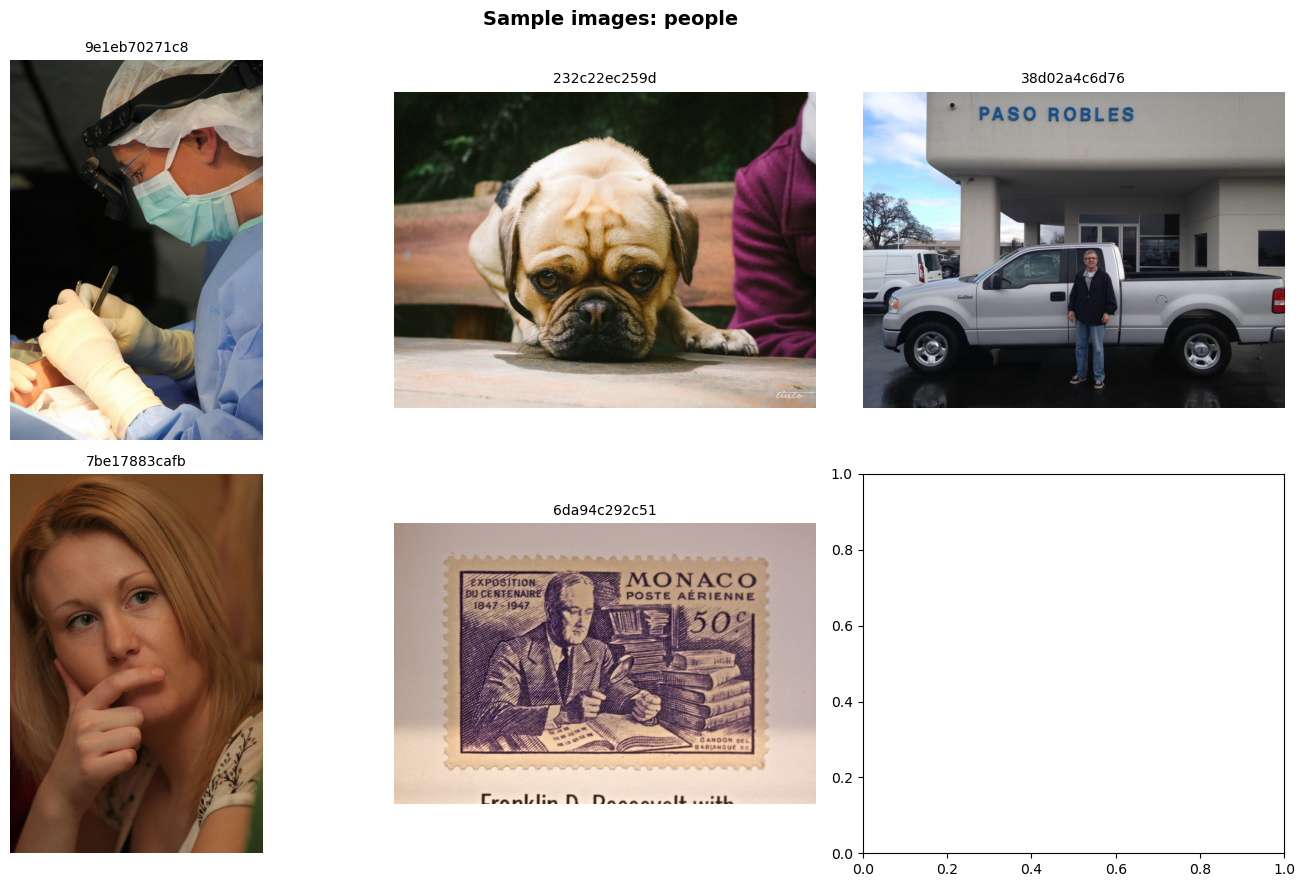

In [8]:
# ============================================
# DOWNLOAD AND DISPLAY 6 SAMPLE IMAGES FROM YOUR CATEGORY
# ============================================

def get_sample_images(category, n=6):
    """Find and download a few sample images from the validation set."""
    class_names = CATEGORY_TO_CLASSES[category]
    class_mids = classes_df[classes_df["class_name"].isin(class_names)]["mid"].tolist()
    
    # Find image IDs
    matching_ids = annotations_df[annotations_df["LabelName"].isin(class_mids)]["ImageID"].unique()
    sample_ids = np.random.choice(matching_ids, size=min(n, len(matching_ids)), replace=False)
    
    # Get URLs
    sample_meta = images_df[images_df["ImageID"].isin(sample_ids)]
    
    # Download and display
    images = []
    for _, row in sample_meta.iterrows():
        try:
            response = urllib.request.urlopen(row["OriginalURL"], timeout=10)
            img = Image.open(BytesIO(response.read()))
            images.append((row["ImageID"], img))
        except Exception as e:
            print(f"  Skipped {row['ImageID']}: {e}")
    
    return images

print(f"Downloading 6 sample images for category: {MY_REAL_CATEGORY}")
print("This may take a moment...\n")

np.random.seed(42)
sample_images = get_sample_images(MY_REAL_CATEGORY, n=6)

if sample_images:
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    for idx, (image_id, img) in enumerate(sample_images[:6]):
        ax = axes[idx // 3][idx % 3]
        ax.imshow(img)
        ax.set_title(image_id[:12], fontsize=10)
        ax.axis('off')
    plt.suptitle(f'Sample images: {MY_REAL_CATEGORY}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No images downloaded. Check your internet connection.")

### YOUR TURN: Dataset Exploration Notes

Look at the sample images above and think about what law enforcement imagery looks like (bodycam footage, surveillance cameras, evidence photos).

**1. Do these images look like what a police officer might encounter? Why or why not?**

Your answer: No. These images show a surgeon, a dog, a stamp, and a woman thinking. A police officer would not typically encounter these kinds of images in their work. Law enforcement imagery looks very different.



**2. What's different about these images compared to typical surveillance/bodycam footage?**

Your answer: These images are clear, well lit, and high quality. Real surveillance footage is usually grainy, dark, low resolution, and shot from overhead angles. These images look like professional photos, not security camera footage.



**3. List 3 search terms that might find more relevant images, and 2 that probably wouldn't work.**

_Good terms:_
1. Person
2. Human body
3. Pedestrian

_Poor terms:_
1. Asian student
2. Black student

---
# Part 2: Download Real Images for Your Category

Now we'll download real images at scale. The process:
1. Query Open Images for your assigned category
2. Filter to the number we need
3. Download the actual image files
4. Save a manifest (log of what we downloaded)

We start with a small test batch (10 images), then scale up.

In [13]:
# ============================================
# FIND IMAGES FOR YOUR CATEGORY
# This uses the validation set. For the full download, we'll use the training set.
# ============================================

def find_images_for_category(category, max_images=None, seed=42):
    """Find image IDs and URLs for a given category."""
    class_names = CATEGORY_TO_CLASSES[category]
    class_mids = classes_df[classes_df["class_name"].isin(class_names)]
    mid_list = class_mids["mid"].tolist()
    mid_to_name = dict(zip(class_mids["mid"], class_mids["class_name"]))
    
    # Filter annotations
    filtered = annotations_df[annotations_df["LabelName"].isin(mid_list)]
    image_ids = filtered["ImageID"].unique()
    print(f"Found {len(image_ids)} total images for '{category}'")
    
    # Sample if needed
    if max_images and len(image_ids) > max_images:
        rng = np.random.default_rng(seed)
        image_ids = rng.choice(image_ids, size=max_images, replace=False)
        print(f"Sampled {max_images} images")
    
    # Get URLs
    result = images_df[images_df["ImageID"].isin(image_ids)][["ImageID", "OriginalURL"]].copy()
    
    # Add class labels
    image_classes = (
        filtered[filtered["ImageID"].isin(image_ids)]
        .groupby("ImageID")["LabelName"]
        .apply(lambda x: ", ".join(sorted(set(mid_to_name.get(m, m) for m in x))))
        .reset_index()
        .rename(columns={"LabelName": "classes_present"})
    )
    result = result.merge(image_classes, on="ImageID", how="left")
    
    return result

# Find images for your category
my_images = find_images_for_category(MY_REAL_CATEGORY, max_images=50)
print(f"\nFirst 5 results:")
my_images.head()

Found 11501 total images for 'people'
Sampled 50 images

First 5 results:


,ImageID,OriginalURL,classes_present
0,ad4526c0bd203b07,https://farm8.staticflickr.com/1417/1185537204...,Person
1,6deddbd0e6ccaae1,https://farm2.staticflickr.com/405/18980978464...,"Girl, Human body, Human face, Person, Woman"
2,8b09e4fcc209ca42,https://farm3.staticflickr.com/304/20143077658...,Person
3,66417fec5acc0c2b,https://c4.staticflickr.com/3/2102/2747160443_...,"Human body, Person"
4,d206a070d6c814e8,https://c1.staticflickr.com/8/7470/15777125176...,"Girl, Human body, Man, Person, Woman"


In [14]:
# ============================================
# DOWNLOAD A TEST BATCH (10 images)
# Start small to make sure everything works before downloading thousands.
# ============================================

TEST_BATCH_SIZE = 10

# Create output directory for your category
my_output_dir = RAW_REAL_DIR / MY_REAL_CATEGORY
my_output_dir.mkdir(parents=True, exist_ok=True)

test_batch = my_images.head(TEST_BATCH_SIZE)
downloaded = []
failed = []

print(f"Downloading {TEST_BATCH_SIZE} test images to {my_output_dir}")
print()

for i, (_, row) in enumerate(test_batch.iterrows()):
    image_id = row["ImageID"]
    url = row["OriginalURL"]
    output_path = my_output_dir / f"{image_id}.jpg"
    
    try:
        if not output_path.exists():
            urllib.request.urlretrieve(url, output_path)
        downloaded.append(output_path)
        print(f"  [{i+1}/{TEST_BATCH_SIZE}] Downloaded {image_id}")
    except Exception as e:
        failed.append(image_id)
        print(f"  [{i+1}/{TEST_BATCH_SIZE}] FAILED {image_id}: {e}")

print(f"\nResults: {len(downloaded)} downloaded, {len(failed)} failed")


  [1/10] Downloaded ad4526c0bd203b07
  [2/10] Downloaded 6deddbd0e6ccaae1
  [3/10] Downloaded 8b09e4fcc209ca42
  [4/10] FAILED 66417fec5acc0c2b: HTTP Error 404: Not Found
  [5/10] Downloaded d206a070d6c814e8
  [6/10] Downloaded c18aa62555d003a8
  [7/10] Downloaded daa339007b1df1f1
  [8/10] Downloaded 5936c50fd0e4f5c1
  [9/10] FAILED 6f69ce7b3af41428: HTTP Error 404: Not Found
  [10/10] Downloaded 18f5b21c06c6f3d1

Results: 8 downloaded, 2 failed


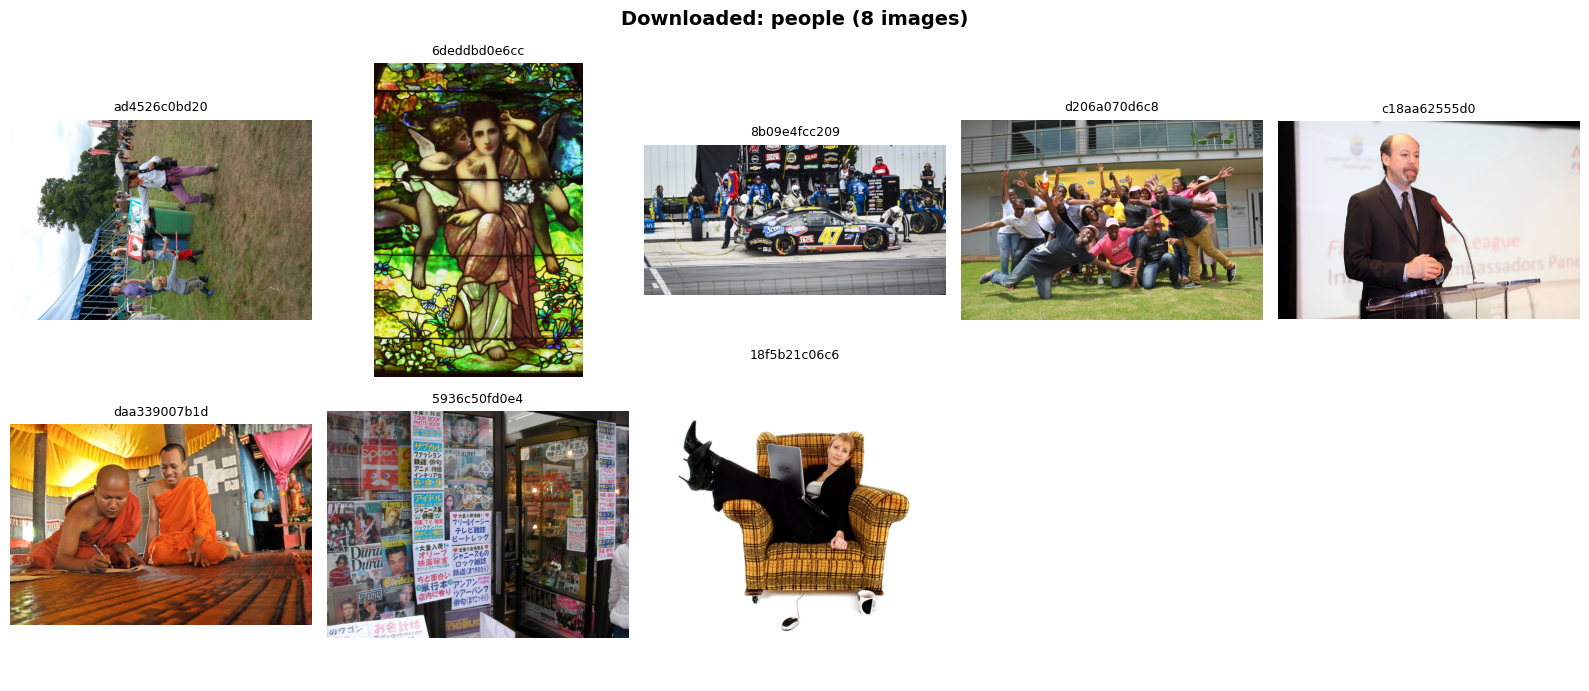

In [15]:
# ============================================
# DISPLAY YOUR DOWNLOADED IMAGES
# ============================================

if downloaded:
    n_show = min(10, len(downloaded))
    cols = 5
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3.5))
    if rows == 1:
        axes = [axes]
    
    for idx, path in enumerate(downloaded[:n_show]):
        ax = axes[idx // cols][idx % cols] if rows > 1 else axes[idx]
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(path.stem[:12], fontsize=9)
        ax.axis('off')
    
    # Hide empty subplots
    for idx in range(n_show, rows * cols):
        ax = axes[idx // cols][idx % cols] if rows > 1 else axes[idx]
        ax.axis('off')
    
    plt.suptitle(f'Downloaded: {MY_REAL_CATEGORY} ({len(downloaded)} images)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No images to display. Check the download cell above for errors.")

In [16]:
# ============================================
# SAVE A MANIFEST (log of what you downloaded)
# This is important for tracking and reproducibility.
# ============================================

manifest_path = my_output_dir / f"manifest_{MY_REAL_CATEGORY}.csv"
test_batch.to_csv(manifest_path, index=False)
print(f"Manifest saved to: {manifest_path}")
print(f"Total images tracked: {len(test_batch)}")

Manifest saved to: c:\Users\USER\ai-generated-image-detection\data\raw\real\people\manifest_people.csv
Total images tracked: 10


### YOUR TURN: Download Observations

**1. How many total images are available for your category in the validation set?**

_Your answer: 11,501 images are available for the people category in the validation set.



**2. Look at the images you downloaded. Are they relevant to law enforcement? Would they look like something from a surveillance camera or bodycam?**

_Your answer: Not really. The images show things like a monk, a stained glass window, a NASCAR race, and a woman sitting in a chair. These are clear, colorful, high quality photos. They do not look like surveillance or bodycam footage which is usually grainy, dark, and shot from overhead angles.



**3. What target count does the project need for your category?** (Check the team assignments table above)

_Your answer: The target count for the people category is 2,500 images.



---
# Part 3: Write Prompts for Synthetic Image Generation

We need AI to generate images that look like law enforcement content. To do that, we write text prompts describing what each image should look like.

Good prompts are **specific** and include:
- The scene or subject
- Camera angle and type (overhead, POV, wide angle)
- Lighting conditions (night, fluorescent, flash)
- Quality markers (grainy, slightly blurry, low resolution)
- Context clues (timestamp overlay, evidence markers)

In [ ]:
# ============================================
# EXAMPLE PROMPTS BY CATEGORY
# Study these examples to understand the style, then write your own.
# ============================================

EXAMPLE_PROMPTS = {
    "surveillance_security": [
        "Grainy overhead surveillance camera footage of a parking garage at night, fluorescent lighting, wide angle, timestamp overlay in corner",
        "Security camera view of a convenience store entrance, fisheye distortion, one person entering, nighttime, motion blur",
        "Black and white CCTV footage of a hotel hallway, overhead angle, empty corridor, harsh ceiling lights casting shadows",
        "Surveillance camera view of an ATM area at night, infrared look, one person at the machine, slight noise artifacts",
        "Parking lot security camera footage during rain, wide angle overhead view, cars parked, wet reflections on pavement, low resolution",
    ],
    "evidence_style": [
        "Close-up photograph of items laid out on a white table for evidence documentation, overhead view, ruler for scale, flash photography",
        "Interior of a room photographed with flash, slightly overexposed, evidence markers numbered 1-5 on the floor",
        "Photograph of a car interior taken through the window, flash glare on glass, items visible on seats and floor",
        "Crime scene style photo of a backpack contents laid out on paper, overhead view, each item separated, bright even lighting",
        "Evidence photo of a desktop with personal items, shot from above with flash, papers and electronics visible, slightly cluttered",
    ],
    "bodycam_style": [
        "Body-worn camera perspective of a traffic stop at night, red and blue lights reflecting off a car, slight motion blur, wide angle",
        "First-person bodycam view walking down a dimly lit apartment hallway, barrel distortion, door numbers visible, green tint",
        "POV bodycam footage of approaching a house front door during daytime, wide angle lens, hand visible reaching for doorbell",
        "Body camera view of a parking lot interaction, two people standing near a vehicle, daytime, slight overexposure from sun",
        "Bodycam perspective looking down at a sidewalk at night, flashlight beam visible, wet pavement, wide angle distortion",
    ],
    "documents": [
        "Photograph of an ID card on a desk, slightly angled, ambient office lighting, some glare on laminated surface",
        "Close-up photo of a handwritten note on lined paper, slightly out of focus at edges, pen visible in frame",
        "Photograph of a receipt on a countertop, flash photography, some text readable, crumpled edges",
        "Photo of a vehicle registration document on a car dashboard, taken through windshield, glare and reflections",
        "Image of several documents spread on a table, overhead view, some partially overlapping, mixed printed and handwritten",
    ],
}

# Show examples for YOUR assigned prompt category
if MY_PROMPT_CATEGORY in EXAMPLE_PROMPTS:
    print(f"Example prompts for: {MY_PROMPT_CATEGORY}")
    print("=" * 60)
    for i, prompt in enumerate(EXAMPLE_PROMPTS[MY_PROMPT_CATEGORY], 1):
        print(f"\n{i}. {prompt}")
else:
    print(f"Fill in MY_PROMPT_CATEGORY above first!")
    print(f"Options: {list(EXAMPLE_PROMPTS.keys())}")

### YOUR TURN: Write Your Prompts

Write **at least 5 prompts** in the cell below. Follow the pattern from the examples:
- Be specific about the scene
- Include camera details (angle, type, distortion)
- Include lighting and quality details
- Think: "What would this actually look like from a bodycam/surveillance camera/evidence photo?"

**Goal for this week:** 50 prompts total. Start with 5 now, add more later.

In [ ]:
# ============================================
# YOUR PROMPTS - Write at least 5 to start
# Replace the examples below with your own.
# ============================================

my_prompts = [
    # Prompt 1:
    "",
    
    # Prompt 2:
    "",
    
    # Prompt 3:
    "",
    
    # Prompt 4:
    "",
    
    # Prompt 5:
    "",
]

# Remove any empty prompts
my_prompts = [p for p in my_prompts if p.strip()]
print(f"You've written {len(my_prompts)} prompts so far.")
print(f"Goal: 50 prompts for {MY_PROMPT_CATEGORY}")
print(f"Progress: {len(my_prompts)}/50")


In [ ]:
# ============================================
# SAVE YOUR PROMPTS TO A FILE
# Run this cell every time you add new prompts.
# ============================================

if not my_prompts:
    print("No prompts written yet. Fill in the cell above first.")
else:
    prompts_dir = PROJECT_ROOT / 'data' / 'prompts'
    prompts_dir.mkdir(parents=True, exist_ok=True)

    prompts_file = prompts_dir / f"{MY_PROMPT_CATEGORY}_prompts_{STUDENT_NAME.lower().replace(' ', '_')}.json"

    prompt_data = {
        "student": STUDENT_NAME,
        "category": MY_PROMPT_CATEGORY,
        "prompts": my_prompts,
        "count": len(my_prompts),
    }

    with open(prompts_file, 'w') as f:
        json.dump(prompt_data, f, indent=2)

    print(f"Saved {len(my_prompts)} prompts to: {prompts_file}")


---
# Part 4: Generate Synthetic Images

Now we use AI to generate images from our prompts. We use **Stable Diffusion XL (SDXL)**, an open-source image generation model.

**Important:** Image generation requires a GPU. If you're on your laptop, this section will be slow or won't work. On TACC, it takes about 5-10 seconds per image.

We'll generate 2-3 test images first, then scale up on TACC.

In [ ]:
# ============================================
# CHECK: Do we have a GPU?
# ============================================
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_mem / 1e9
    print(f"GPU available: {gpu_name} ({gpu_mem:.1f} GB)")
    print("You can generate images in this notebook!")
    DEVICE = "cuda"
else:
    print("No GPU detected. You're probably on your laptop.")
    print("That's OK! You can still:")
    print("  - Write and save prompts (Part 3)")
    print("  - Work on degradation (Part 5)")
    print("  - Do readings (Part 6)")
    print("\nFor generation, use this notebook on TACC instead.")
    DEVICE = "cpu"

In [ ]:
# ============================================
# LOAD THE IMAGE GENERATION MODEL (GPU ONLY)
# This downloads ~6.5 GB the first time. On TACC it's cached.
# Skip this cell if you don't have a GPU.
# ============================================

if DEVICE == "cuda":
    from diffusers import StableDiffusionXLPipeline
    
    print("Loading Stable Diffusion XL... (this takes 1-2 minutes the first time)")
    pipe = StableDiffusionXLPipeline.from_pretrained(
        "stabilityai/stable-diffusion-xl-base-1.0",
        torch_dtype=torch.float16,
        variant="fp16",
    )
    pipe = pipe.to("cuda")
    print("Model loaded and ready!")
else:
    print("Skipping model load (no GPU). Run this on TACC to generate images.")
    pipe = None

In [ ]:
# ============================================
# GENERATE TEST IMAGES FROM YOUR PROMPTS
# We'll generate 2 images to test. Skip if no GPU.
# ============================================

def generate_image(pipe, prompt, seed=42):
    """Generate one image from a text prompt."""
    generator = torch.Generator(device="cuda").manual_seed(seed)
    image = pipe(
        prompt=prompt,
        num_inference_steps=30,
        guidance_scale=7.5,
        generator=generator,
    ).images[0]
    return image

if pipe is not None and len(my_prompts) > 0:
    test_prompts = my_prompts[:2]  # Just test with 2
    generated_images = []
    
    for i, prompt in enumerate(test_prompts):
        print(f"Generating image {i+1}/{len(test_prompts)}...")
        print(f"  Prompt: {prompt[:80]}...")
        img = generate_image(pipe, prompt, seed=42 + i)
        generated_images.append((prompt, img))
        
        # Save it
        out_dir = RAW_SYNTHETIC_DIR / MY_SYNTHETIC_CATEGORY
        out_dir.mkdir(parents=True, exist_ok=True)
        img.save(out_dir / f"test_{i:04d}.png")
    
    # Display
    fig, axes = plt.subplots(1, len(generated_images), figsize=(8 * len(generated_images), 8))
    if len(generated_images) == 1:
        axes = [axes]
    for idx, (prompt, img) in enumerate(generated_images):
        axes[idx].imshow(img)
        axes[idx].set_title(prompt[:50] + "...", fontsize=10, wrap=True)
        axes[idx].axis('off')
    plt.suptitle("Generated Test Images", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
elif pipe is None:
    print("No GPU available. Skip this cell and run on TACC.")
else:
    print("Write some prompts in Part 3 first!")

In [ ]:
# ============================================
# BATCH GENERATION (for scaling up on TACC)
# Use this cell when you're ready to generate all your images.
# ============================================

def batch_generate(pipe, prompts, output_dir, category, seeds_per_prompt=5, start_seed=42):
    """
    Generate multiple images per prompt to reach our target count.
    Each prompt generates `seeds_per_prompt` variations using different seeds.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    total = len(prompts) * seeds_per_prompt
    count = 0
    
    print(f"Generating {total} images ({len(prompts)} prompts x {seeds_per_prompt} seeds)")
    print(f"Output: {output_dir}")
    
    manifest = []
    
    for p_idx, prompt in enumerate(prompts):
        for s_idx in range(seeds_per_prompt):
            seed = start_seed + p_idx * 100 + s_idx
            filename = f"{category}_{p_idx:03d}_seed{seed:05d}.png"
            filepath = output_dir / filename
            
            if filepath.exists():
                count += 1
                continue
            
            img = generate_image(pipe, prompt, seed=seed)
            img.save(filepath)
            
            manifest.append({
                "filename": filename,
                "prompt": prompt,
                "seed": seed,
                "model": "stabilityai/stable-diffusion-xl-base-1.0",
            })
            
            count += 1
            if count % 10 == 0:
                print(f"  Progress: {count}/{total}")
    
    # Save manifest
    manifest_df = pd.DataFrame(manifest)
    manifest_df.to_csv(output_dir / "generation_manifest.csv", index=False)
    
    print(f"\nDone! Generated {count} images.")
    return manifest_df

# Uncomment when ready to run on TACC:
# batch_generate(
#     pipe=pipe,
#     prompts=my_prompts,
#     output_dir=RAW_SYNTHETIC_DIR / MY_SYNTHETIC_CATEGORY,
#     category=MY_SYNTHETIC_CATEGORY,
#     seeds_per_prompt=5,
# )

print("Batch generation function ready.")
print("Uncomment the code above and run on TACC when you have your prompts finalized.")

### YOUR TURN: Generation Observations

If you generated test images (or look at a teammate's), answer these:

**1. Do the generated images look realistic? What gives them away as AI-generated?**

_Your answer:_



**2. How do they compare to the real images from Part 2? What's different?**

_Your answer:_



**3. How would you improve your prompts to make images look more like real law enforcement content?**

_Your answer:_



---
# Part 5: Degradation Pipeline

Real bodycam and surveillance footage is never pristine. It's compressed, blurry, noisy, and low-resolution. To make our benchmark realistic, we degrade both real and synthetic images to three quality levels:

| Level | Simulates | What We Do |
|-------|-----------|------------|
| **Clean** | Original quality | Nothing (baseline) |
| **Moderate** | Decent surveillance | JPEG compression (Q50) + slight blur + reduced contrast |
| **Heavy** | Bad bodycam / old CCTV | JPEG compression (Q30) + downscale 50% + noise + blur |

The key question: **Do detection tools still work when image quality drops?**

In [ ]:
# ============================================
# DEGRADATION FUNCTIONS
# These apply realistic quality degradation to images.
# ============================================

def apply_jpeg_compression(img, quality=50):
    """Compress image with JPEG artifacts."""
    buffer = BytesIO()
    img.save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)
    return Image.open(buffer).copy()

def apply_gaussian_blur(img, sigma=1.0):
    """Apply Gaussian blur."""
    return img.filter(ImageFilter.GaussianBlur(radius=sigma))

def apply_contrast_reduction(img, factor=0.8):
    """Reduce contrast. factor < 1 = less contrast."""
    enhancer = ImageEnhance.Contrast(img)
    return enhancer.enhance(factor)

def apply_gaussian_noise(img, sigma=25):
    """Add random Gaussian noise."""
    arr = np.array(img, dtype=np.float32)
    noise = np.random.normal(0, sigma, arr.shape)
    noisy = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy)

def apply_downscale(img, factor=0.5):
    """Downscale then upscale back (simulates low-res capture)."""
    w, h = img.size
    small = img.resize((int(w * factor), int(h * factor)), Image.BILINEAR)
    return small.resize((w, h), Image.BILINEAR)


def degrade_clean(img):
    """Clean version: no degradation."""
    return img.copy()

def degrade_moderate(img):
    """Moderate: decent surveillance footage quality."""
    img = apply_jpeg_compression(img, quality=50)
    img = apply_gaussian_blur(img, sigma=1.0)
    img = apply_contrast_reduction(img, factor=0.8)
    return img

def degrade_heavy(img):
    """Heavy: poor bodycam / old CCTV quality."""
    img = apply_jpeg_compression(img, quality=30)
    img = apply_downscale(img, factor=0.5)
    img = apply_gaussian_noise(img, sigma=25)
    img = apply_gaussian_blur(img, sigma=2.0)
    return img

print("Degradation functions loaded!")
print("Levels: clean, moderate, heavy")

In [ ]:
# ============================================
# APPLY DEGRADATION TO A SAMPLE IMAGE
# Let's see the three quality levels side by side.
# ============================================

# Pick a sample image (use one we downloaded, or any image file)
sample_files = list(my_output_dir.glob("*.jpg"))

if sample_files:
    sample_path = sample_files[0]
    original = Image.open(sample_path)
    
    # Apply all three degradation levels
    clean = degrade_clean(original)
    moderate = degrade_moderate(original)
    heavy = degrade_heavy(original)
    
    # Display side by side
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(clean)
    axes[0].set_title('Clean (original)', fontsize=13, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(moderate)
    axes[1].set_title('Moderate (surveillance)', fontsize=13, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(heavy)
    axes[2].set_title('Heavy (bad bodycam)', fontsize=13, fontweight='bold')
    axes[2].axis('off')
    
    plt.suptitle('Degradation Levels Comparison', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"Image: {sample_path.name}")
    print(f"Original size: {original.size}")
else:
    print("No downloaded images found. Run Part 2 first to download some images.")

In [ ]:
# ============================================
# APPLY DEGRADATION TO ALL YOUR DOWNLOADED IMAGES
# This creates the 3 versions (clean/moderate/heavy) of each image.
# ============================================

def process_dataset(input_dir, category, image_type="real"):
    """
    Apply all degradation levels to images in a directory.
    
    Args:
        input_dir: Directory containing source images
        category: Category name (for organizing output)
        image_type: 'real' or 'synthetic'
    """
    levels = {
        "clean": degrade_clean,
        "moderate": degrade_moderate,
        "heavy": degrade_heavy,
    }
    
    image_files = list(Path(input_dir).glob("*.jpg")) + list(Path(input_dir).glob("*.png"))
    print(f"Processing {len(image_files)} images from {input_dir}")
    
    for level_name, degrade_fn in levels.items():
        out_dir = DATA_DIR / 'processed' / level_name / image_type / category
        out_dir.mkdir(parents=True, exist_ok=True)
        
        count = 0
        for img_path in image_files:
            out_path = out_dir / img_path.name
            if out_path.exists():
                continue
            
            try:
                img = Image.open(img_path).convert('RGB')
                degraded = degrade_fn(img)
                degraded.save(out_path, quality=85)
                count += 1
            except Exception as e:
                print(f"  Error processing {img_path.name}: {e}")
        
        print(f"  {level_name}: {count} new images saved to {out_dir}")

# Process your downloaded real images
process_dataset(my_output_dir, MY_REAL_CATEGORY, image_type="real")
print("\nDone! Check data/processed/ for the results.")

### YOUR TURN: Degradation Observations

**1. Look at the three versions. Which degradation level makes it hardest to identify what's in the image?**

_Your answer:_



**2. If you were a detection tool trying to spot AI-generated images, why would degraded images be harder to analyze?**

_Your answer:_



**3. Does the heavy degradation look realistic compared to actual surveillance or bodycam footage you've seen (in movies, news, etc.)?**

_Your answer:_



---
# Part 6: Reading Notes

Each team member has assigned readings. Summarize each one below in **3-5 sentences**.
Focus on: What did they do? What did they find? Why does it matter for our project?

### Reading 1: ___

_Title/source:_

_Summary (3-5 sentences):_




### Reading 2: ___

_Title/source:_

_Summary (3-5 sentences):_




### Reading 3 (optional): ___

_Title/source:_

_Summary (3-5 sentences):_




---
# Part 7: Progress Tracker

Update this section each week so Dr. Scruse (and you) can see your progress at a glance.

In [ ]:
# ============================================
# YOUR PROGRESS - Update these numbers as you work
# ============================================

prompts_written = len(my_prompts) if "my_prompts" in dir() else 0
real_downloaded = len(list(my_output_dir.glob("*.jpg"))) if "my_output_dir" in dir() and my_output_dir.exists() else 0
synth_generated = len(list((RAW_SYNTHETIC_DIR / MY_SYNTHETIC_CATEGORY).glob("*.png"))) if (RAW_SYNTHETIC_DIR / MY_SYNTHETIC_CATEGORY).exists() else 0

progress = {
    "prompts_written": (prompts_written, 50),
    "real_images_downloaded": (real_downloaded, CONFIG["dataset"]["real_categories"].get(MY_REAL_CATEGORY, 0)),
    "synthetic_images_generated": (synth_generated, CONFIG["dataset"]["synthetic_categories"].get(MY_SYNTHETIC_CATEGORY, 0)),
    "readings_completed": (0, 2),  # Update manually
}

print(f"Progress Report for {STUDENT_NAME}")
print("=" * 45)
for task, (count, target) in progress.items():
    pct = (count / target * 100) if target > 0 else 0
    bar = "#" * int(pct / 5) + "-" * (20 - int(pct / 5))
    print(f"  {task:<30} [{bar}] {count}/{target} ({pct:.0f}%)")


---
# What's Next

After completing this notebook:

1. **Scale up real image downloads** - Change `TEST_BATCH_SIZE` to your full target count and re-run Part 2 (use the training set for more images)
2. **Write all 50 prompts** - Keep adding to the `my_prompts` list in Part 3
3. **Generate on TACC** - Run Part 4's batch generation cell on TACC with a GPU
4. **Process everything** - Run Part 5's `process_dataset` on all your images
5. **Commit and push** - Save your work to GitHub

```bash
git add notebooks/portfolios/your_name.ipynb
git add data/prompts/
git commit -m "Add portfolio notebook and prompts"
git push origin main
```

Questions? Message Dr. Scruse. Don't spin your wheels for more than 15 minutes.